## Read data 

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("insurance_data.csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


### Plot a scatter plot

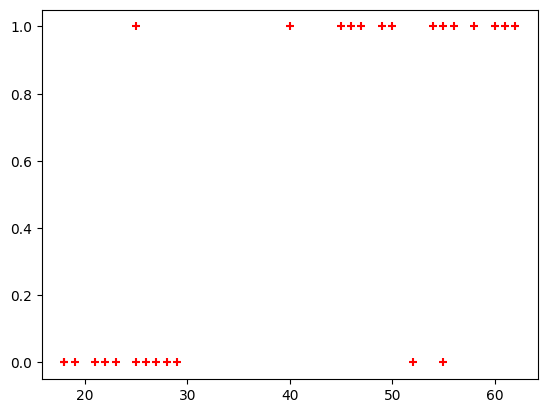

In [11]:
plt.scatter(df.age, df.bought_insurance, marker= "+", color ='red')

### Split your dataset

In [13]:
X_train, X_test,y_train,y_test = train_test_split(df[['age']],df.bought_insurance,test_size =0.1)

NameError: name 'train_test_split' is not defined

In [ ]:
X_test

### Create an Object

In [ ]:
model = LogisticRegression()

### Train the model

In [ ]:
model.fit(X_train,y_train)

### Make predictions

In [ ]:
model.predict(X_test)

### Look at the score ( accurcy of your model)

In [ ]:
model.score(X_test,y_test)

### Predicting the probability

In [ ]:
model.predict_proba(X_test)

## Predict values

In [ ]:
model.predict([[20]])

# HR ANALYTICS 

### Import libraries

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import numpy as np

In [15]:
hr = pd.read_csv("HR_comma_sep.csv")
hr.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [16]:
hr.shape

(14999, 10)

## Check stastistical Distribution

In [17]:
hr.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [18]:
hr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Check Null values 

In [19]:
hr.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

#### How Many Employees left  (Target Variable)

In [20]:
vc = hr['left'].value_counts()

Employee_left = pd.DataFrame({
    'left': vc.index,
    'count': vc.values
})

Employee_left['percentage'] = (
    Employee_left['count'] / Employee_left['count'].sum() * 100
).round(1).astype(str) + '%'

Employee_left

,left,count,percentage
0,0,11428,76.2%
1,1,3571,23.8%


#####  Plot a bar graph to show correlation between Salary and rentention

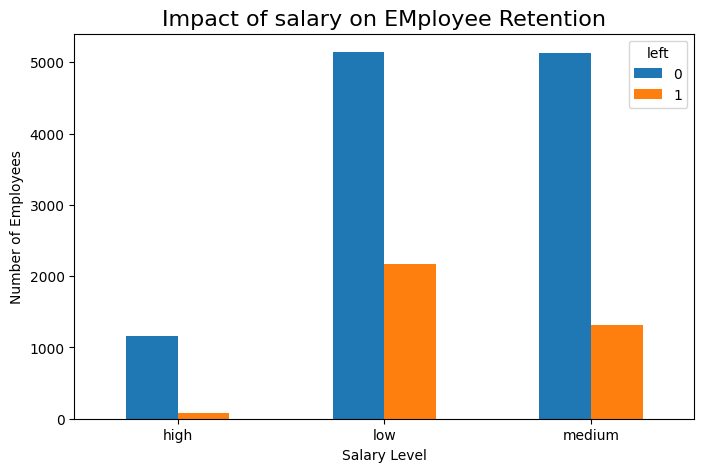

In [21]:
pd.crosstab(hr.salary,hr.left).plot(kind ='bar', figsize=(8,5))
plt.title("Impact of salary on EMployee Retention", fontsize=16)
plt.xlabel("Salary Level")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.show()
          

Observation: Low salary people are leaving the most
             High salary almost no one leaves

### DEPARMENT - WISE RETENTION

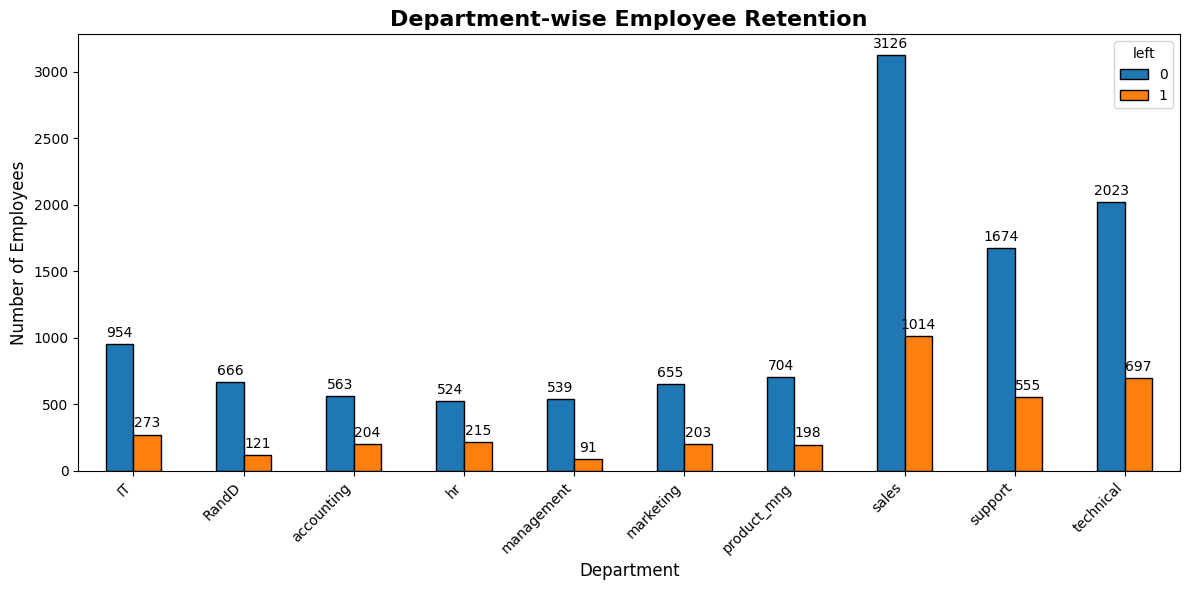

In [22]:
# Crosstab
ct = pd.crosstab(hr["Department"], hr["left"])

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ct.plot(kind='bar', ax=ax, edgecolor='black')

# Titles and labels
ax.set_title("Department-wise Employee Retention", fontsize=16, weight='bold')
ax.set_xlabel("Department", fontsize=12)
ax.set_ylabel("Number of Employees", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Add bar labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()


Observation: Sales , technical , support have high turnover (Sales, technical are big departments


#### WHICH VARIABLES ACTUALLY MATTER?

In [23]:
# List only the numeric columns you want to aggregate
cols_to_average = [
    'satisfaction_level',
    'last_evaluation',
    'number_project',
    'average_montly_hours',
    'time_spend_company',
    'Work_accident',
    'promotion_last_5years'
]
# Group by 'left' and take the mean of these columns
grouped_means = hr.groupby('left')[cols_to_average].mean()

grouped_means.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


Collecting Insights:
Satisfaction level - huge drop when left
Average_monthly_hours - leavers work more
promotion_last_5years - almost no promotion for leavers


### let's select these columns 

In [24]:
imp_cols = ['satisfaction_level','average_montly_hours','promotion_last_5years','salary']
df_final = hr[imp_cols]
df_final.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary
0,0.38,157,0,low
1,0.80,262,0,medium
2,0.11,272,0,medium
3,0.72,223,0,low
4,0.37,159,0,low


####  CONVERT SALARY TO DUMMY VARIABLE

In [25]:
salary_dummies = pd.get_dummies(df_final.salary, 
                                prefix="salary", 
                                drop_first=True).astype(int)

df_with_dummies = pd.concat([df_final, salary_dummies], axis=1)
df_with_dummies.drop('salary', axis=1, inplace=True)

df_with_dummies.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary_low,salary_medium
0,0.38,157,0,1,0
1,0.80,262,0,0,1
2,0.11,272,0,0,1
3,0.72,223,0,1,0
4,0.37,159,0,1,0


### TRAIN -TEST SPLIT

In [26]:
X = df_with_dummies
y = hr.left
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.25, random_state =42)

print("Training size :", X_train.shape)
print("Training size :", X_test.shape)

Training size : (11249, 5)
Training size : (3750, 5)


### BUILD LOGISTIC REGRESSION MODEL

In [27]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
# Coefficients
pd.DataFrame(model.coef_.T, index=X.columns, columns=['Coefficient'])

,Coefficient
satisfaction_level,-3.820939
average_montly_hours,0.002552
promotion_last_5years,-1.150209
salary_low,1.711267
salary_medium,1.262746


### MODEL ACCURACY

In [29]:
model.score(X_test, y_test)

0.7634666666666666

## Predict

In [31]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.93      0.86      2853
           1       0.51      0.24      0.33       897

    accuracy                           0.76      3750
   macro avg       0.65      0.58      0.59      3750
weighted avg       0.73      0.76      0.73      3750



In [33]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[2649,  204],
       [ 683,  214]])

##### Predict for a new employee 

In [34]:
def will_he_leave(satisfaction, hours, promotion, salary):
    low = 1 if salary == 'low' else 0
    medium = 1 if salary == 'medium' else 0
    
    prob = model.predict_proba([[satisfaction, hours, promotion, low, medium]])[0][1]
    print(f"Probability of leaving = {prob:.3f} → {'YES' if prob>0.5 else 'NO'}")

# Examples
will_he_leave(0.3, 270, 0, 'low')      # 
will_he_leave(0.8, 160, 1, 'high')     # 
will_he_leave(0.5, 200, 0, 'medium') 

Probability of leaving = 0.574 → YES
Probability of leaving = 0.009 → NO
Probability of leaving = 0.251 → NO


C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


### SAVE MODEL

In [36]:
import joblib
# Save the model
joblib.dump(model, 'hr_turnover_model.pkl')

print("Model saved successfully!")

Model saved successfully!


### Create Streamlit App

In [38]:
import streamlit as st
import joblib
import numpy as np


## Load  the model

In [39]:
model = joblib.load('hr_turnover_model.pkl')

### Title & Description

In [ ]:
st.title(" Employee Turnover Prediction")
st.markdown("### Will this employee leave the company? Let's find out!")
st.image("https://img.freepik.com/free-vector/recruit-agent-analyzing-candidates_74855-4565.jpg?w=2000", use_column_width=True)
st.sidebar.header("Employee Details")

### Input fields

In [41]:
satisfaction = st.sidebar.slider("Satisfaction Level", 0.0, 1.0, 0.5, 0.01)
hours = st.sidebar.slider("Average Monthly Hours", 80, 310, 200)
promotion = st.sidebar.selectbox("Promotion in Last 5 Years?", (0, 1))
salary = st.sidebar.selectbox("Salary Level", ('low', 'medium', 'high'))
# Prepare input for model
if salary == 'low':
    salary_low, salary_medium = 1, 0
elif salary == 'medium':
    salary_low, salary_medium = 0, 1
else:
    salary_low, salary_medium = 0, 0

# Prediction
if st.sidebar.button("Predict Turnover Risk"):
    prob = model.predict_proba([[satisfaction, hours, promotion, salary_low, salary_medium]])[0][1]
    
    st.markdown(f"""
    <div style="padding: 20px; border-radius: 10px; background-color: #f0f2f6;">
        <h2 style="color: #ff4444;">Probability of Leaving: <b>{prob:.1%}</b></h2>
    </div>
    """, unsafe_allow_html=True)
    
    if prob > 0.6:
        st.error("HIGH RISK - This employee is very likely to leave!")
        st.markdown("**Recommendations**: Give salary hike, promotion, or talk to them urgently.")
    elif prob > 0.3:
        st.warning("MEDIUM RISK - Keep an eye on this employee.")
    else:
        st.success("LOW RISK - This employee is happy and likely to stay!")
    
    # Bonus: Show feature importance
    st.markdown("### Why this prediction?")
    st.write(f"- Satisfaction: {satisfaction} → {'Very Bad' if satisfaction < 0.4 else 'Okay' if satisfaction < 0.7 else 'Good'}")
    st.write(f"- Monthly Hours: {hours} → {'Overworked!' if hours > 250 else 'Normal'}")
    st.write(f"- Promotion: {'No' if promotion == 0 else 'Yes'}")
    st.write(f"- Salary: {salary.capitalize()}")

st.caption("Model built using Logistic Regression | Accuracy ~78% ")

2025-11-20 12:11:25.217 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-20 12:11:25.220 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-20 12:11:25.222 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-20 12:11:25.224 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-20 12:11:25.225 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-20 12:11:25.228 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-20 12:11:25.231 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-20 12:11:25.232 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()